<a href="https://colab.research.google.com/github/mrbedoya/ml-2026/blob/main/08_MaquinasVectoresSoporte_Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Máquinas de Vectores de Soporte Regresión (SVM)

## 1. Librerias y configuraciones previas


In [1]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib

# Gestion de librerias
# ==============================================================================
from importlib import reload

# Matemáticas y estadísticas
# ==============================================================================
import math

# Preprocesado y modelado
# ==============================================================================

#Separar los datos entrenamiento y prueba
from sklearn.model_selection import train_test_split

#Escalar Variables
from sklearn.preprocessing import MinMaxScaler

#Configuracion de hiperparámetros
from sklearn.model_selection import ParameterGrid, GridSearchCV

#Creación de modelo
from sklearn.ensemble import RandomForestClassifier

# Evaluación del modelo
from sklearn.metrics import classification_report

#Creación de modelo
from sklearn.svm import SVR

#Evaluación del modelo
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             median_absolute_error)

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Interuactuar con os y solicitudes desde HTTP
# ==============================================================================
import os
import sys
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Parametros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/mrbedoya/ml-2026/main/'

# Nombres de los archivos requeridos
DATASET_FILE_NAME = '01_carDetailsV4_Prep.csv'
UTILS_FILE_NAME = 'funciones.py'

# Nombres de los directorios para utilidades, datasets y modelos
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'
MODELS_PATH = 'modelos/'
MODELS_REGRESION_PATH = os.path.join(MODELS_PATH, 'regresion')
MODELS_SCALER_PATH = os.path.join(MODELS_PATH, 'scaler')

# URL completa del dataset y utils en GitHub
github_dataset_url = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME)
github_utils_url = os.path.join(GITHUB_BASE_URL, UTILS_PATH, UTILS_FILE_NAME)

# Rutas locales completas de datasets y utils
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

In [3]:
## Cargar datos desde Google Drive
## ==============================================================================

#from google.colab import drive

## Montar Google Drive
#drive.mount('/gdrive')

## Establece el directorio de trabajo dentro de directorio espefíficado en Google Drive
#os.chdir("/gdrive/MyDrive/01_Academia/02_Cursos/20260401_ApredinzajeAutomáticoI_UdeA/")

## Listar archivos de directorio
##!ls

In [4]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [5]:
# Configuración entorno Colab
# ==============================================================================

# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Crear subdirectorios específicos para modelos y escalados
os.makedirs(MODELS_REGRESION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

# Descarga de archivos
download_file(github_dataset_url, local_dataset_path, "dataset")
download_file(github_utils_url, local_utils_path, "funciones")

Descargando dataset desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/datasets/01_carDetailsV4_Prep.csv
dataset descargado exitosamente a: datasets/01_carDetailsV4_Prep.csv
Descargando funciones desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


## 2. Funciones

In [6]:
## Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
#sys.path.append(UTILS_PATH)

## Importar Funciones externas
#from funciones import multiple_plot

## 3. Carga del dataset

In [7]:
#Se crea un dataframe d con los datos obtenidos de archivo de entrada
d=pd.read_csv(local_dataset_path)

In [8]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Price               1441 non-null   float64
 1   Year                1441 non-null   float64
 2   Kilometer           1441 non-null   float64
 3   Engine              1441 non-null   float64
 4   Length              1441 non-null   float64
 5   Width               1441 non-null   float64
 6   Height              1441 non-null   float64
 7   Seating Capacity    1441 non-null   float64
 8   Fuel Tank Capacity  1441 non-null   float64
 9   Fuel Type           1441 non-null   object 
 10  Transmission        1441 non-null   object 
 11  Owner               1441 non-null   object 
 12  Seller Type         1441 non-null   object 
 13  Drivetrain          1441 non-null   object 
 14  PriceRange          1441 non-null   int64  
dtypes: float64(9), int64(1), object(5)
memory usage: 169.0+

## 4. Visualización de datos

### Variables de entrada

In [9]:
#Lista de variables categóricas
catCols = d.select_dtypes(include = ["object", 'category']).columns.tolist()

d[catCols].head(2)

,Fuel Type,Transmission,Owner,Seller Type,Drivetrain
0,Petrol,Automatic,First,Individual,FWD
1,Diesel,Automatic,First,Corporate,AWD


In [10]:
#Lista de variables numéricas

numCols=d.select_dtypes(include = ['float64','float64','int32','int64']).columns.tolist()
d[numCols].head(2)

,Price,Year,Kilometer,Engine,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,PriceRange
0,9540.0,2021.0,9000.0,1199.0,3993.0,1677.0,1532.0,5.0,35.0,1
1,10500.0,2014.0,99000.0,2199.0,4690.0,1880.0,1690.0,7.0,64.0,1


In [11]:
##Visualización de frecuencia de instancias para variables categóricas
#multiple_plot(3, d , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

In [12]:
#Visualización por medio de gráficos de caja de bigotes para las variables categóricas con respecto al precio
#multiple_plot(3, d , catCols, 'Price', 'boxplot', 'Distribución de la variable Make vs. el Price',30)

In [13]:
#Visualización de variables numéricas con respecto al precio
#multiple_plot(1, d , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

In [14]:
#Eliminar la variable de salida de la lista de variable numéricas
numCols.remove('Price')

### Variable de salida

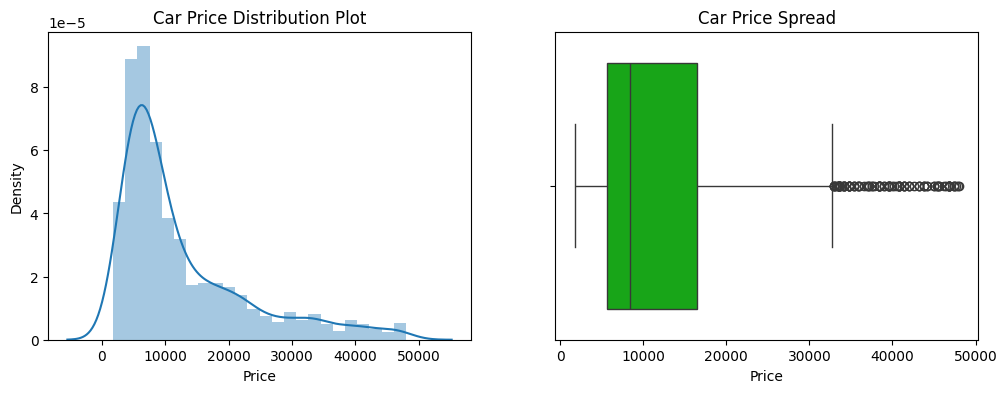

In [15]:
#Histográma y caja de bigotes del precio de los vehículos

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title('Car Price Distribution Plot')
sns.distplot(d.Price)

plt.subplot(1,2,2)
plt.title('Car Price Spread')
sns.boxplot(x=d.Price, palette='nipy_spectral')

plt.show()

In [16]:
pd.set_option('display.float_format', lambda x: '%.0f' % x)

print(d.Price.describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.975,1]))

count    1441
mean    12601
std     10255
min      1740
25%      5580
50%      8388
75%     16500
85%     22500
90%     28800
95%     35880
97.5%   41400
100%    48000
max     48000
Name: Price, dtype: float64


## 5. Preparación de datos

### Creación de Variables Dummies

In [17]:
# Aplicación de la función de usuario Dummies: one-hot encoding

d =pd.get_dummies(d, drop_first=1)

In [18]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Price                   1441 non-null   float64
 1   Year                    1441 non-null   float64
 2   Kilometer               1441 non-null   float64
 3   Engine                  1441 non-null   float64
 4   Length                  1441 non-null   float64
 5   Width                   1441 non-null   float64
 6   Height                  1441 non-null   float64
 7   Seating Capacity        1441 non-null   float64
 8   Fuel Tank Capacity      1441 non-null   float64
 9   PriceRange              1441 non-null   int64  
 10  Fuel Type_Otro          1441 non-null   bool   
 11  Fuel Type_Petrol        1441 non-null   bool   
 12  Transmission_Manual     1441 non-null   bool   
 13  Owner_Fourth            1441 non-null   bool   
 14  Owner_Second            1441 non-null   

## 6. Creación del modelo

### Dividir el conjunto de datos

In [19]:
#Se establece las variables de entrada 'X' y la variable de salida 'y'

X = d.drop(columns = "Price")
y = d['Price']

In [20]:
# División de los datos en train y test

#En este caso, el 80% de los datos se utilizarán para entrenar el modelo.

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

### Escalar Variables

In [21]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numerivas para posteriormente escalarlas
num_vars = numCols

print(num_vars)

['Year', 'Kilometer', 'Engine', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity', 'PriceRange']


In [22]:
#Escalar Variables númericas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,Year,Kilometer,Engine,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,PriceRange
99,0.8235,0.4393,0.1016,0.1992,0.2613,0.3195,0.5000,0.2192,0.2000
1251,0.8235,0.3630,0.1044,0.3231,0.3814,0.2908,0.5000,0.1370,0.2000


### Creación del modelo

**Parámetros importantes**

- **C** (default = 1.0): Parámetro de regularización. La fuerza de la regularización es inversamente proporcional a C.Debe ser estrictamente positiva.La penalización es una penalización l2 al cuadrado. Un valor alto de C dará como resultado un modelo más complejo que se ajusta muy bien a los datos de entrenamiento pero puede tener problemas de sobreajuste (overfitting) en datos nuevos.

    
- **kernel** (default=’rbf’):
Especifica el tipo de kernel que se utilizará en el algoritmo. Debe ser ‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’ o invocable.


- **degreeint** (default=3)
Grado de la función del núcleo polinomial ('poly'). Ignorado por todos los demás núcleos.
   

- **gamma** {‘scale’, ‘auto’} or float, default=’scale’
Coeficiente de kernel para 'rbf', 'poli' y 'sigmoide'. ‘rbf’, ‘poly’ and ‘sigmoid’.

    - Si 'scale' usa 1 / (n_features * X.var())

    - Si ‘auto’ usa 1 / n_features.

- **epsilon** {default=0.1} controla el ancho de la zona de tolerancia alrededor de la línea de regresión. Los puntos que caen dentro de esta zona no son considerados errores de predicción.





### Método de retención (*holdout method*)

In [23]:
SVMR_linear    = SVR(kernel='linear' , C = 1000)
SVMR_Pol2   = SVR(kernel='poly'   , C = 1000, degree = 2)
SVMR_Pol3   = SVR(kernel='poly'   , C = 1000, degree = 3)
SVMR_rbf   = SVR(kernel='rbf'    , C = 1000)
SVMR_sig   = SVR(kernel='sigmoid', C = 1000)


SVMR_linear.fit(X_train, y_train)
SVMR_Pol2.fit(X_train, y_train)
SVMR_Pol3.fit(X_train, y_train)
SVMR_rbf.fit(X_train, y_train)
SVMR_sig.fit(X_train, y_train)


SVR(C=1000, kernel='sigmoid')

### Evaluación del modelo

In [24]:
print('Linear   Training: ', SVMR_linear.score(X_train,y_train), 'Test:',r2_score(y_test,SVMR_linear.predict(X_test)))
print('Poly 2   Training: ', SVMR_Pol2.score(X_train,y_train), 'Test:',r2_score(y_test,SVMR_Pol2.predict(X_test)))
print('Poly 3   Training: ', SVMR_Pol3.score(X_train,y_train), 'Test:',r2_score(y_test,SVMR_Pol3.predict(X_test)))
print('rbf      Training: ', SVMR_rbf.score(X_train,y_train), 'Test:',r2_score(y_test,SVMR_rbf.predict(X_test)))
print('sigmoide Training: ', SVMR_sig.score(X_train,y_train), 'Test:',r2_score(y_test,SVMR_sig.predict(X_test)))


Linear   Training:  0.7677778506151033 Test: 0.8050004356466465
Poly 2   Training:  0.809622949976236 Test: 0.8345080157437513
Poly 3   Training:  0.8548812209364811 Test: 0.8683461654854103
rbf      Training:  0.7376684087070482 Test: 0.7721230145259722
sigmoide Training:  0.48436582387225224 Test: 0.5257387017749192


## 7. Afinando el modelo (tuning)

### Preparacion de datos

In [25]:
# Nuevamente se asigna a 'X_Completo' y 'y_Completo' los datos entrada y salida respectivamente
X_Completo = X
y_Completo = y

# Se escalan los datos numéricos de entrada
X_Completo[num_vars] = scaler.fit_transform(X_Completo[num_vars])

In [26]:
# Guardar el scaler
joblib.dump(scaler, './modelos/scaler/minmaxFull_carDetailsV4.pkl')

['./modelos/scaler/minmaxFull_carDetailsV4.pkl']

In [27]:
X_Completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    1441 non-null   float64
 1   Kilometer               1441 non-null   float64
 2   Engine                  1441 non-null   float64
 3   Length                  1441 non-null   float64
 4   Width                   1441 non-null   float64
 5   Height                  1441 non-null   float64
 6   Seating Capacity        1441 non-null   float64
 7   Fuel Tank Capacity      1441 non-null   float64
 8   PriceRange              1441 non-null   float64
 9   Fuel Type_Otro          1441 non-null   bool   
 10  Fuel Type_Petrol        1441 non-null   bool   
 11  Transmission_Manual     1441 non-null   bool   
 12  Owner_Fourth            1441 non-null   bool   
 13  Owner_Second            1441 non-null   bool   
 14  Owner_Third             1441 non-null   

### Identificando los mejores hiperparámetros

In [28]:
#Se entena el modelo con múltiples hiperparámetros buscando el mejor

#Se crea una instancia de una SVR Regression
modelsvr = SVR()

CV = 10

#Se establecen los hiperparámetros para el Kernel lineal
svm_linear = {'C': [0.1, 1, 10, 100, 1000],
              'kernel': ['linear']}

#Se establecen los hiperparámetros para el Kernel polinomico
svm_poly = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 'auto', 'scale'],
              'degree': [2, 3],
              'kernel': ['poly']}

#Se establecen los hiperparámetros para los kernels rbf y sigmoid
svm_others = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001,'auto', 'scale'],
              'kernel': [ 'rbf', 'sigmoid']}

#Se unen todos los hiperparametros en una lista de diccionarios
parameters = [svm_linear, svm_poly, svm_others]


# Se define un GridSearchCV con una validacion cruzada de 10 pliegues y con todos los
#hierparametros establecidos anteriormente
grid_svr = GridSearchCV(modelsvr,
                        param_grid=parameters,
                        cv=CV,
                        verbose=3)

#Se entrena el GridSearchCV anterior (2 min. aprox.) con los datos completos
grid_svr.fit(X_Completo,y_Completo)

Fitting 10 folds for each of 125 candidates, totalling 1250 fits
[CV 1/10] END ............C=0.1, kernel=linear;, score=-0.126 total time=   0.1s
[CV 2/10] END ............C=0.1, kernel=linear;, score=-0.268 total time=   0.1s
[CV 3/10] END ............C=0.1, kernel=linear;, score=-0.176 total time=   0.1s
[CV 4/10] END ............C=0.1, kernel=linear;, score=-0.166 total time=   0.1s
[CV 5/10] END ............C=0.1, kernel=linear;, score=-0.173 total time=   0.1s
[CV 6/10] END ............C=0.1, kernel=linear;, score=-0.125 total time=   0.1s
[CV 7/10] END ............C=0.1, kernel=linear;, score=-0.182 total time=   0.1s
[CV 8/10] END ............C=0.1, kernel=linear;, score=-0.174 total time=   0.2s
[CV 9/10] END ............C=0.1, kernel=linear;, score=-0.137 total time=   0.1s
[CV 10/10] END ...........C=0.1, kernel=linear;, score=-0.115 total time=   0.1s
[CV 1/10] END ..............C=1, kernel=linear;, score=-0.062 total time=   0.1s
[CV 2/10] END ..............C=1, kernel=line

GridSearchCV(cv=10, estimator=SVR(),
             param_grid=[{'C': [0.1, 1, 10, 100, 1000], 'kernel': ['linear']},
                         {'C': [0.1, 1, 10, 100, 1000], 'degree': [2, 3],
                          'gamma': [1, 0.1, 0.01, 0.001, 'auto', 'scale'],
                          'kernel': ['poly']},
                         {'C': [0.1, 1, 10, 100, 1000],
                          'gamma': [1, 0.1, 0.01, 0.001, 'auto', 'scale'],
                          'kernel': ['rbf', 'sigmoid']}],
             verbose=3)

In [29]:
#grid_svr.cv_results

In [30]:
# Obtener los resultados del grid search
results_grid_svr = pd.DataFrame(grid_svr.cv_results_)


# Seleccionar las columnas deseadas
columns_grid_svr = ['param_C']  + \
                    ['param_degree']  + \
                    ['param_kernel']  + \
                    ['param_gamma']   + \
                    ['mean_test_score', 'std_test_score']  + \
                    [f'split{i}_test_score' for i in range(CV)]

# Filtrar y mostrar los resultados
results_grid_svr_filtered = results_grid_svr[columns_grid_svr]

# Crear la columna scoreWithStd: R2 / std
results_grid_svr_filtered['scoreWithStd'] = results_grid_svr_filtered.apply(
    lambda row: row['mean_test_score'] / row['std_test_score'] if row['std_test_score'] != 0 else 0,
    axis=1
)

# Encuentra el índice del máximo valor en la columna scoreWithStd
indice_max_scoreWithStd = results_grid_svr_filtered['scoreWithStd'].idxmax()

# Mostrar los scores promedios por cada parámetro
print(results_grid_svr_filtered[['param_C', 'param_degree', 'mean_test_score', 'std_test_score', 'scoreWithStd']])


      param_C  param_degree  mean_test_score  std_test_score  scoreWithStd
0      0.1000           NaN          -0.1640          0.0419       -3.9156
1      1.0000           NaN          -0.1083          0.0418       -2.5882
2     10.0000           NaN           0.2157          0.0433        4.9794
3    100.0000           NaN           0.6351          0.0288       22.0422
4   1000.0000           NaN           0.7742          0.0245       31.5435
..        ...           ...              ...             ...           ...
120 1000.0000           NaN          -0.1083          0.0418       -2.5882
121 1000.0000           NaN           0.6297          0.0312       20.1918
122 1000.0000           NaN           0.5592          0.0326       17.1427
123 1000.0000           NaN           0.7559          0.0324       23.3617
124 1000.0000           NaN           0.4513          0.0362       12.4648

[125 rows x 5 columns]


In [31]:
# Se identifican los mejores hiperparámetros
best_params = grid_svr.best_params_
print('Best Parameters : ',best_params)

Best Parameters :  {'C': 1000, 'degree': 3, 'gamma': 1, 'kernel': 'poly'}


In [32]:
# Top 3 de los mejores scores
results_grid_svr_filtered.sort_values(by='scoreWithStd', ascending=False).head(3)[
    ['param_C', 'param_degree', 'param_kernel','param_gamma','mean_test_score', 'std_test_score', 'scoreWithStd']]

,param_C,param_degree,param_kernel,param_gamma,mean_test_score,std_test_score,scoreWithStd
53,1000.0000,2.0000,poly,1,0.8792,0.0238,36.9335
47,100.0000,3.0000,poly,1,0.8805,0.0277,31.8009
4,1000.0000,NaN,linear,NaN,0.7742,0.0245,31.5435


In [33]:
# Seleccionar el registro correspondiente al índice máximo
registro_max_scoreWithStd = results_grid_svr_filtered.loc[indice_max_scoreWithStd]

registro_max_scoreWithStd.transpose()

,53
param_C,1000.0000
param_degree,2.0000
param_kernel,poly
param_gamma,1
mean_test_score,0.8792
std_test_score,0.0238
split0_test_score,0.9086
split1_test_score,0.8969
split2_test_score,0.9001
split3_test_score,0.8805


In [34]:
results_grid_svr_filtered.loc[indice_max_scoreWithStd]['mean_test_score']

np.float64(0.8791742866424569)

### Creación del modelo final

In [35]:
# Usar los mejores parámetros para crear el modelo
#modelsvr.set_params(**best_params)

#modelsvr.fit(X_Completo, y_Completo)

In [36]:
# # Se crea un modelo SVR con los mejores hiperparámetros
# modelsvr = SVR( kernel = best_params["kernel"]
#                    , gamma = best_params["gamma"]
#                    , C= best_params["C"]
#                    , degree = best_params["degree"])
#
#
# #Se entrena el modelo con los datos completos
# modelsvr.fit(X_Completo, y_Completo)

In [37]:
# Usar los mejores parámetros para crear el modelo
modelsvr.set_params(kernel=results_grid_svr_filtered.loc[indice_max_scoreWithStd]['param_kernel']
                     , C = results_grid_svr_filtered.loc[indice_max_scoreWithStd]['param_C']
                     , gamma = results_grid_svr_filtered.loc[indice_max_scoreWithStd]['param_gamma']
                     , degree =  int(results_grid_svr_filtered.loc[indice_max_scoreWithStd]['param_degree'])
                    )

modelsvr.fit(X_Completo, y_Completo)

SVR(C=np.float64(1000.0), degree=2, gamma=1, kernel='poly')

### Guardar modelo

In [40]:
#Se guarda el modelo de SVR

MODEL_FILE_NAME = 'SVR_CV_poly.pkl'
local_model_path = os.path.join(MODELS_REGRESION_PATH, MODEL_FILE_NAME)

joblib.dump(modelsvr,  local_model_path)

['modelos/regresion/SVR_CV_poly.pkl']

#### Referencias


- *Machine learning con Python y Scikit-learn:*
    - https://www.cienciadedatos.net/documentos/py06_machine_learning_python_scikitlearn.html
    

- *scikit-learn:*    
    - https://scikit-learn.org/stable/
    - https://scikit-learn.org/stable/user_guide.html
  
  
- *Gráficas con  seaborn:*
    - https://ichi.pro/es/como-utilizar-python-seaborn-para-analisis-de-datos-exploratorios-28897898172180





- *Analítica de grandes datos:*
    - https://jdvelasq.github.io/courses/analitica-de-grandes-datos/index.html